# Project 04 — Divorce ~ Marriage + Age (multiple linear regression)

**Tier 1 · Foundations** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P04_divorce-multiple/P04_divorce-multiple_12-06-2026_Opus48.ipynb)

The first **multiple** regression. US-state divorce rate as a function of two predictors — marriage rate
**M** and median age at marriage **A**. New skills: **standardizing** every variable to mean 0 / sd 1 so
priors are interpretable, and reading a small **DAG** to understand **confounding** — why the raw
marriage-rate association nearly vanishes once age at marriage is controlled.

## Learning objectives
1. Build a multiple linear regression `D ~ a + bM·M + bA·A` on **standardized** variables.
2. Understand **standardization**: coefficients become "sd of outcome per sd of predictor", so a
   `Normal(0, 0.5)` prior is weakly-informative and comparable across predictors.
3. Read a **DAG** (`M ← A → D`, `M → D`) and see **confounding** in action: `bM` shrinks toward 0 once
   A enters the model — age at marriage explains most of the apparent marriage-rate effect.
4. Compare `D~A`, `D~M`, `D~M+A` with **PSIS-LOO**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 4
rng = np.random.default_rng(RANDOM_SEED)
def zscore(x): x = np.asarray(x, float); return (x - x.mean()) / x.std()
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate from known a = 0, bM = 0.1, bA = −0.6, σ = 0.7 on two **standardized** predictors; fit; confirm
each truth lands inside its 90% HDI.

In [2]:
a_t, bM_t, bA_t, s_t = 0.0, 0.10, -0.60, 0.70
n = 200
M_sim = rng.normal(0, 1, n); A_sim = rng.normal(0, 1, n)
D_sim = rng.normal(a_t + bM_t*M_sim + bA_t*A_sim, s_t)
with pm.Model() as m0:
    a = pm.Normal("a", 0, 0.2); bM = pm.Normal("bM", 0, 0.5); bA = pm.Normal("bA", 0, 0.5)
    s = pm.Exponential("s", 1)
    pm.Normal("D", a + bM*M_sim + bA*A_sim, s, observed=D_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name, tr in [("a",a_t),("bM",bM_t),("bA",bA_t),("s",s_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bM, bA, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


     mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a  -0.024  -0.104    0.055    1.0    4319.0
bM  0.129   0.044    0.210    1.0    4072.0
bA -0.617  -0.699   -0.539    1.0    4793.0
s   0.703   0.645    0.761    1.0    4178.0
a recovered: True
bM recovered: True
bA recovered: True
s recovered: True


## Data load — WaffleDivorce (`;`-delimited)

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/WaffleDivorce.csv"
CACHE = "data/WaffleDivorce.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
print("shape:", df.shape)
df[["Location","Divorce","Marriage","MedianAgeMarriage"]].head()

loaded from raw URL
shape: (50, 13)


,Location,Divorce,Marriage,MedianAgeMarriage
0,Alabama,12.7,20.2,25.3
1,Alaska,12.5,26.0,25.2
2,Arizona,10.8,20.3,25.8
3,Arkansas,13.5,26.4,24.3
4,California,8.0,19.1,26.8


## Stage 1–2 — Question & EDA
**Question:** controlling for age at marriage, is the **marriage rate** itself associated with the
**divorce rate** across US states? **Target:** the standardized coefficient `bM`.
We **standardize** D = Divorce, M = Marriage, A = MedianAgeMarriage to mean 0 / sd 1. After
standardizing, `bM` reads "sd of divorce per +1 sd of marriage rate", directly comparable to `bA`.

n states = 50
corr(M, D)  = +0.37
corr(A, D)  = -0.60
corr(M, A)  = -0.72   <- M and A are strongly related (confounding)


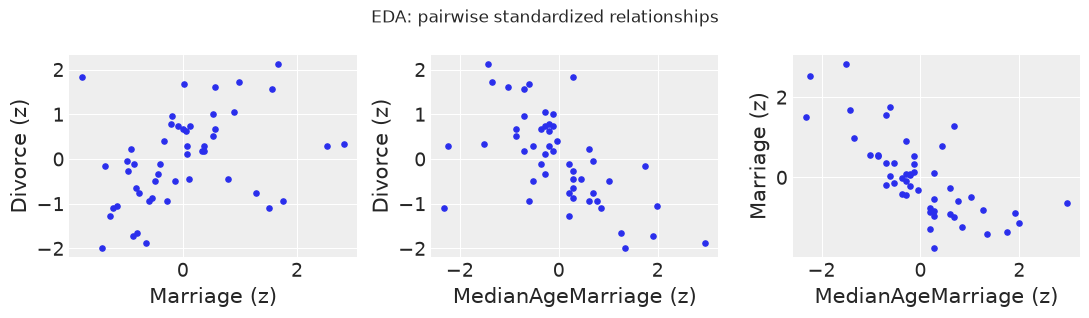

In [4]:
D = zscore(df["Divorce"].values)
M = zscore(df["Marriage"].values)
A = zscore(df["MedianAgeMarriage"].values)
print(f"n states = {len(D)}")
print(f"corr(M, D)  = {np.corrcoef(M, D)[0,1]:+.2f}")
print(f"corr(A, D)  = {np.corrcoef(A, D)[0,1]:+.2f}")
print(f"corr(M, A)  = {np.corrcoef(M, A)[0,1]:+.2f}   <- M and A are strongly related (confounding)")
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].scatter(M, D, s=14); ax[0].set_xlabel("Marriage (z)"); ax[0].set_ylabel("Divorce (z)")
ax[1].scatter(A, D, s=14); ax[1].set_xlabel("MedianAgeMarriage (z)"); ax[1].set_ylabel("Divorce (z)")
ax[2].scatter(A, M, s=14); ax[2].set_xlabel("MedianAgeMarriage (z)"); ax[2].set_ylabel("Marriage (z)")
plt.suptitle("EDA: pairwise standardized relationships"); plt.tight_layout(); plt.show()

## The DAG — why this is a confounding problem
$$A \rightarrow D, \quad A \rightarrow M, \quad M \rightarrow D\ (?)$$
Median **age at marriage A** is a common cause of both the **marriage rate M** and the **divorce rate D**:
states where people marry later have *fewer* marriages per capita **and** fewer divorces. So the raw
M–D correlation is partly a back-door path `M ← A → D`. Conditioning on A closes that back-door; whatever
is left in `bM` is the direct M → D effect (which we will find is ≈ 0).

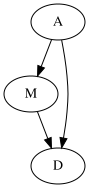

In [5]:
try:
    import graphviz
    g = graphviz.Digraph()
    g.edge("A", "M"); g.edge("A", "D"); g.edge("M", "D")
    display(g)
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: A->M, A->D, M->D")

## Stage 3 — Model specification (full model `D ~ M + A`)
$$D_i \sim \mathrm{Normal}(\mu_i, \sigma), \quad \mu_i = a + b_M M_i + b_A A_i,$$
$$a \sim \mathrm{Normal}(0, 0.2), \quad b_M, b_A \sim \mathrm{Normal}(0, 0.5), \quad \sigma \sim \mathrm{Exponential}(1).$$
Because everything is standardized, `a ~ Normal(0, 0.2)` says the line passes near the origin, and the
slope priors allow effects up to ≈ ±1 sd-per-sd — generous but not absurd.

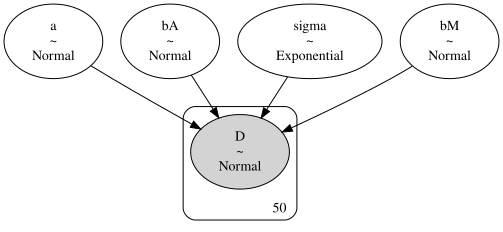

In [6]:
def make_model(use_M=True, use_A=True):
    with pm.Model() as mdl:
        a = pm.Normal("a", 0, 0.2)
        mu = a
        if use_M:
            bM = pm.Normal("bM", 0, 0.5); mu = mu + bM*M
        if use_A:
            bA = pm.Normal("bA", 0, 0.5); mu = mu + bA*A
        sigma = pm.Exponential("sigma", 1)
        pm.Normal("D", mu, sigma, observed=D)
    return mdl
model = make_model(True, True)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| a,bM,bA,sigma -> D")

## Stage 4 — Prior predictive on the OUTCOME scale (standardized divorce)
Draw lines from the prior over the observed A-range and check the implied standardized divorce values are
in a sane band (roughly within ±2–3 sd), not exploding.

Sampling: [D, a, bA, bM, sigma]


prior predictive D (z): mean +0.00, sd 1.72, 1-99% [-5.07, +5.19]


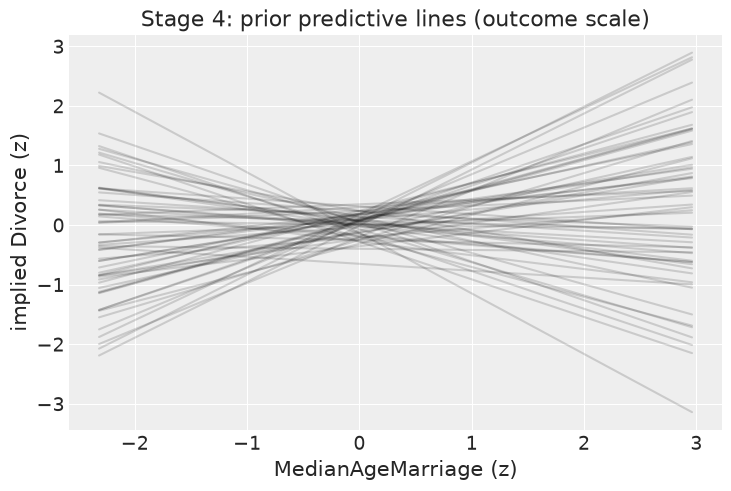

In [7]:
with model:
    pp = pm.sample_prior_predictive(samples=200, random_seed=RANDOM_SEED)
prior_D = pp.prior_predictive["D"].values.reshape(-1)
print(f"prior predictive D (z): mean {prior_D.mean():+.2f}, sd {prior_D.std():.2f}, "
      f"1-99% [{np.percentile(prior_D,1):+.2f}, {np.percentile(prior_D,99):+.2f}]")
Aseq = np.linspace(A.min(), A.max(), 30)
ap = pp.prior["a"].values.reshape(-1)[:60]; bAp = pp.prior["bA"].values.reshape(-1)[:60]
for ai, bi in zip(ap, bAp):
    plt.plot(Aseq, ai + bi*Aseq, "k", alpha=.15)
plt.xlabel("MedianAgeMarriage (z)"); plt.ylabel("implied Divorce (z)")
plt.title("Stage 4: prior predictive lines (outcome scale)"); plt.show()

## Stage 5 — Fit (full model)

In [8]:
t0 = time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bM, bA, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [D]


wall-clock 4.9s


## Stage 6 — Diagnostics

        mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a     -0.002  0.098  -0.182    0.182    1.0    3581.0    2673.0
bM    -0.062  0.158  -0.361    0.236    1.0    3008.0    2651.0
bA    -0.611  0.160  -0.908   -0.308    1.0    2929.0    2500.0
sigma  0.836  0.087   0.672    0.992    1.0    3401.0    2689.0

divergences: 0 | BFMI: [1.079 1.029 0.935 1.106]


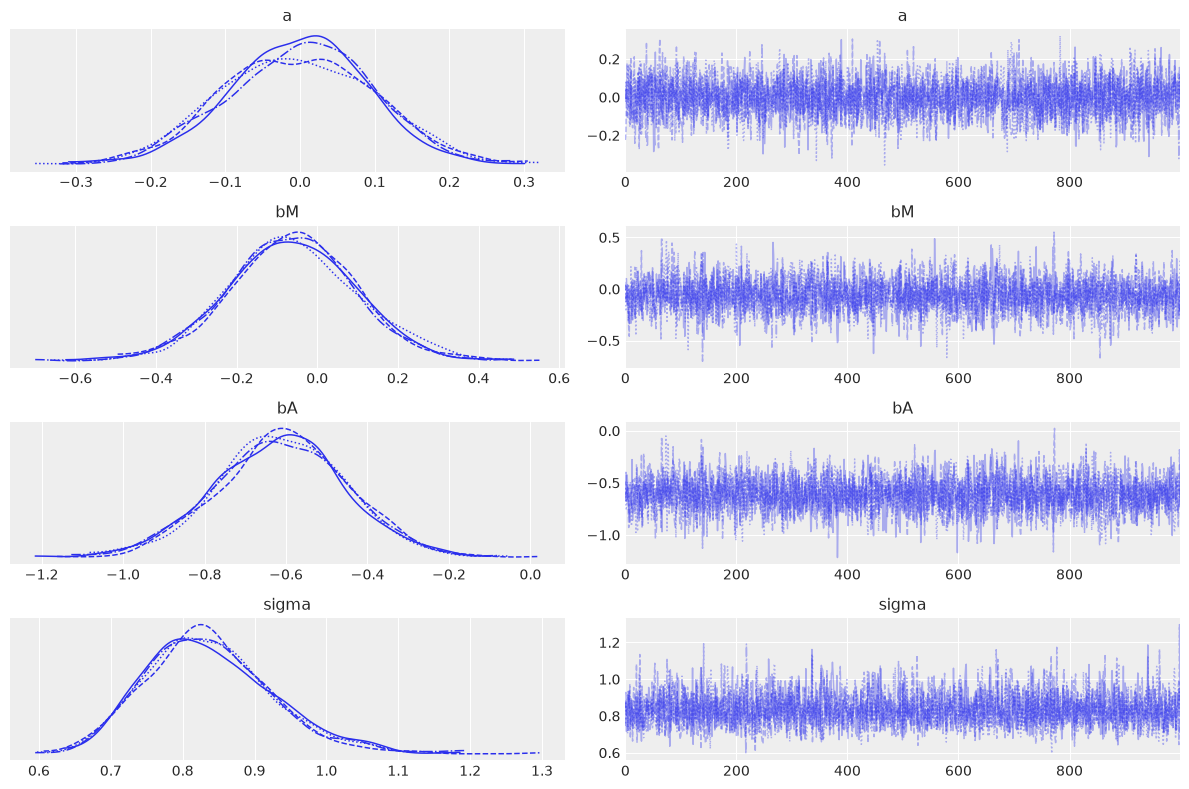

In [9]:
summ = az.summary(idata, var_names=["a","bM","bA","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a","bM","bA","sigma"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation: the confounding revealed
We fit all three models and put `bM` side by side. In `D~M` alone, marriage rate looks predictive; once
age at marriage A is added, `bM` collapses toward 0 — the back-door path `M ← A → D` explained it.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bA, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bM, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


bM in  D~M      : +0.34  (94% HDI +0.10, +0.59)
bM in  D~M+A    : -0.06  (94% HDI -0.36, +0.24)  <- shrinks to ~0
bA in  D~M+A    : -0.61  (94% HDI -0.91, -0.31)  <- the real driver


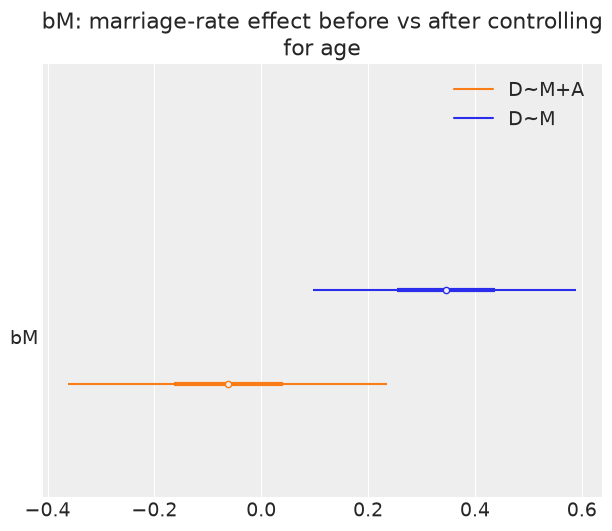

In [10]:
model_A  = make_model(use_M=False, use_A=True)
model_M  = make_model(use_M=True,  use_A=False)
with model_A:
    idata_A = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                        progressbar=False, idata_kwargs={"log_likelihood": True})
with model_M:
    idata_M = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                        progressbar=False, idata_kwargs={"log_likelihood": True})
bM_solo = idata_M.posterior["bM"].mean().item(); bM_solo_hdi = az.hdi(idata_M, var_names=["bM"], hdi_prob=0.94)["bM"].values
bM_full = idata.posterior["bM"].mean().item();   bM_full_hdi = az.hdi(idata,   var_names=["bM"], hdi_prob=0.94)["bM"].values
bA_full = idata.posterior["bA"].mean().item();   bA_full_hdi = az.hdi(idata,   var_names=["bA"], hdi_prob=0.94)["bA"].values
print(f"bM in  D~M      : {bM_solo:+.2f}  (94% HDI {bM_solo_hdi[0]:+.2f}, {bM_solo_hdi[1]:+.2f})")
print(f"bM in  D~M+A    : {bM_full:+.2f}  (94% HDI {bM_full_hdi[0]:+.2f}, {bM_full_hdi[1]:+.2f})  <- shrinks to ~0")
print(f"bA in  D~M+A    : {bA_full:+.2f}  (94% HDI {bA_full_hdi[0]:+.2f}, {bA_full_hdi[1]:+.2f})  <- the real driver")
az.plot_forest([idata_M, idata], model_names=["D~M","D~M+A"], var_names=["bM"], combined=True, hdi_prob=0.94)
plt.title("bM: marriage-rate effect before vs after controlling for age"); plt.show()

## Stage 8 — Posterior predictive check (continuous discrepancy stats)

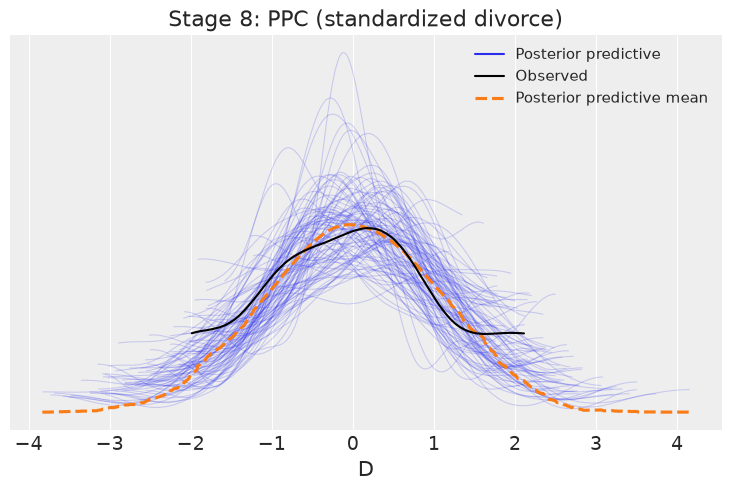

  mean: obs= -0.000  bayes-p=0.48
  sd  : obs= +1.000  bayes-p=0.50
  min : obs= -1.991  bayes-p=0.22
  max : obs= +2.115  bayes-p=0.58


In [11]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC (standardized divorce)"); plt.show()
ppc = idata.posterior_predictive["D"].values.reshape(-1, D.size)
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(D):+7.3f}  bayes-p={(fn(ppc,axis=1)>=fn(D)).mean():.2f}")

## Stage 9 — Comparison: `D~A` vs `D~M` vs `D~M+A` (PSIS-LOO)
The competition that demonstrates confounding numerically: `D~A` already captures almost all the
predictive signal; adding M (the full model) barely helps, and `D~M` alone is clearly worse.

In [12]:
cmp = az.compare({"D~A": idata_A, "D~M": idata_M, "D~M+A": idata})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size * idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
maxk = max(az.loo(x, pointwise=True).pareto_k.values.max() for x in [idata_A, idata_M, idata])
print(f"\nmax Pareto k-hat across models: {maxk:.2f} | threshold {thr:.2f}")
print(f"best model: {cmp.index[0]}")
row2 = cmp.iloc[1]
print(f"elpd_diff of 2nd-ranked = {row2['elpd_diff']:.2f} +/- {row2['dse']:.2f} SE")

       rank   elpd_loo  elpd_diff       dse        weight
D~A       0 -64.018838   0.000000  0.000000  8.846104e-01
D~M+A     1 -64.340710   0.321871  0.529665  3.144690e-16
D~M       2 -70.165980   6.147142  4.984924  1.153896e-01



max Pareto k-hat across models: 0.91 | threshold 0.70
best model: D~A
elpd_diff of 2nd-ranked = 0.32 +/- 0.53 SE


## Stage 10 — Power-scaling prior sensitivity (`bM`, `bA`)

In [13]:
post = az.extract(idata)
ad = post["a"].values; bMd = post["bM"].values; bAd = post["bA"].values; sd_ = post["sigma"].values
logprior = (st.norm.logpdf(ad,0,0.2) + st.norm.logpdf(bMd,0,0.5)
            + st.norm.logpdf(bAd,0,0.5) + st.expon.logpdf(sd_, scale=1))
print("alpha    E[bM]    E[bA]")
for al in [0.8, 1.0, 1.25]:
    wgt = np.exp((al-1)*logprior); wgt /= wgt.sum()
    print(f" {al:4.2f}   {np.sum(wgt*bMd):+.3f}   {np.sum(wgt*bAd):+.3f}")

alpha    E[bM]    E[bA]
 0.80   -0.071   -0.625
 1.00   -0.062   -0.611
 1.25   -0.050   -0.595


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** the natural expansion is to add the **South** indicator or other state-level
covariates, or to model **measurement error** in the divorce/marriage rates using the `Divorce SE` /
`Marriage SE` columns — that error-in-variables model is built in full in **P17**.

**Decision (Stage 12) — headline:** *across US states, the apparent association between the marriage rate
and the divorce rate is **almost entirely confounded by age at marriage**: once A is controlled, bM ≈ 0,
while bA remains a clear negative driver — states where people marry later divorce less.*

In [14]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P04_idata.nc"); print("saved report/P04_idata.nc")

saved report/P04_idata.nc


## Exercises
1. Add the `South` indicator (1 = southern state). Does it change `bA`? Does it have its own effect?
2. Build a **counterfactual** plot: fix A at its mean and vary M — show the model predicts essentially
   no change in D (the visual proof that `bM ≈ 0`).
3. Refit on the **raw** (unstandardized) scale. Show that the priors `Normal(0,0.5)` are now wildly
   inappropriate, and explain why standardization made the priors portable.